In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from config import AGGREGATIONS, BENCHMARKS, RANDOM_SEED
from utils import load_dataset, plot_pool_distribution, print_summary, SOURCE_MAP
from scoring.runner import score_source, scores_path
from selection import select_source, save_selection

AGGREGATION = "10min"
BENCHMARK = "DRIFT"
AGG_PARAMS = AGGREGATIONS[AGGREGATION]
BENCH_PARAMS = BENCHMARKS[BENCHMARK]
STEP_MINUTES = 24 * 60 // AGG_PARAMS["daily_period"]

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

print(f"Benchmark: {BENCHMARK}")
print(f"Aggregation: {AGGREGATION}")
print(f"Threshold: {BENCH_PARAMS['metric_col']} — custom (has_drift & drift_in_test)")
print(f"Rel-dev threshold: {BENCH_PARAMS['threshold']} | Min drift: {BENCH_PARAMS['min_drift_days']} days")
print(f"Sparsity min: {BENCH_PARAMS['sparsity_min']}")
print(f"Sample size: {BENCH_PARAMS['sample_size']} | Seed: {RANDOM_SEED}")

Benchmark: DRIFT
Aggregation: 10min
Threshold: max_rel_dev — custom (has_drift & drift_in_test)
Rel-dev threshold: 0.3 | Min drift: 14 days
Sparsity min: 0.9
Sample size: 25 | Seed: 42


## 1 — Scoring

Detect data drift using rolling moving-average deviation.
A series has drift when the relative deviation between short-term and long-term MAs exceeds a threshold for a sustained period, and the drift overlaps with the test set.
If a score file already exists it is loaded from disk; otherwise `score_source` runs the full computation.

In [2]:
sources = BENCH_PARAMS["levels"]
scores = {}

for source in sources:
    path = scores_path(AGGREGATION, BENCHMARK, source)
    if os.path.exists(path):
        print(f"Loading existing scores: {path}")
        scores[source] = pd.read_csv(path)
    else:
        print(f"Computing scores for {source}...")
        scores[source] = score_source(BENCHMARK, source, aggregation=AGGREGATION)

for source, df in scores.items():
    print(f"\n{source}: {len(df)} series scored")
    display(df.describe().round(3))

Loading existing scores: scores/10min/DRIFT_institutions.csv
Loading existing scores: scores/10min/DRIFT_subnets.csv
Loading existing scores: scores/10min/DRIFT_ips.csv

institutions: 283 series scored


,id_institution,ratio_active,max_rel_dev,drift_fraction,n_drift_events
count,283.000,283.000,283.000,283.000,283.000
mean,142.233,0.916,0.746,0.011,0.657
std,82.480,0.216,0.527,0.025,0.963
min,0.000,0.000,0.000,0.000,0.000
25%,71.500,0.978,0.530,0.000,0.000
50%,142.000,0.999,0.733,0.000,0.000
75%,213.500,1.000,0.959,0.012,1.000
max,284.000,1.000,3.401,0.200,5.000



subnets: 548 series scored


,id_institution_subnet,ratio_active,max_rel_dev,drift_fraction,n_drift_events
count,548.000,548.000,548.000,548.000,548.000
mean,273.500,0.813,0.782,0.018,0.752
std,158.338,0.322,0.806,0.046,1.184
min,0.000,0.000,0.000,0.000,0.000
25%,136.750,0.788,0.000,0.000,0.000
50%,273.500,0.994,0.675,0.000,0.000
75%,410.250,1.000,0.995,0.013,1.000
max,547.000,1.000,3.424,0.551,7.000



ips: 1000 series scored


,id_ip,ratio_active,max_rel_dev,drift_fraction,n_drift_events
count,1000.000,1000.000,1000.000,1000.000,1000.000
mean,860461.454,0.170,0.074,0.003,0.082
std,679140.522,0.265,0.387,0.025,0.536
min,11.000,0.003,0.000,0.000,0.000
25%,266825.500,0.019,0.000,0.000,0.000
50%,635072.500,0.055,0.000,0.000,0.000
75%,1629478.250,0.155,0.000,0.000,0.000
max,2044888.000,1.000,3.426,0.355,6.000


## 2 — Score distributions

Two scalar statistics summarize the qualifying rule per series: $S_p$ (the maximum amplitude sustained over any contiguous $p$-day window in the timeline, equivalent to `has_drift`) and $S_p^{\,\text{test}}$ (the same maximum restricted to the test region, equivalent to `drift_in_test` — the actual qualifying criterion). Both are precomputed in the `DRIFT_SWEEP_*.csv` files. Bars to the right of the threshold in the second plot form the pool that §3 samples from.

In [4]:
sweep_scores = {}
for source in sources:
    _, id_col = SOURCE_MAP[source]
    sweep_path = scores_path(AGGREGATION, "DRIFT_SWEEP", source)
    df = pd.read_csv(sweep_path)
    if df[id_col].dtype == object:
        df[id_col] = df[id_col].str.strip('() ,"').astype(int)
    df = df[df["ratio_active"] >= BENCH_PARAMS["sparsity_min"]].reset_index(drop=True)
    sweep_scores[source] = df
    print(f"  {source}: {len(df)} pass sparsity >= {BENCH_PARAMS['sparsity_min']}")

  institutions: 235 pass sparsity >= 0.9
  subnets: 373 pass sparsity >= 0.9
  ips: 47 pass sparsity >= 0.9


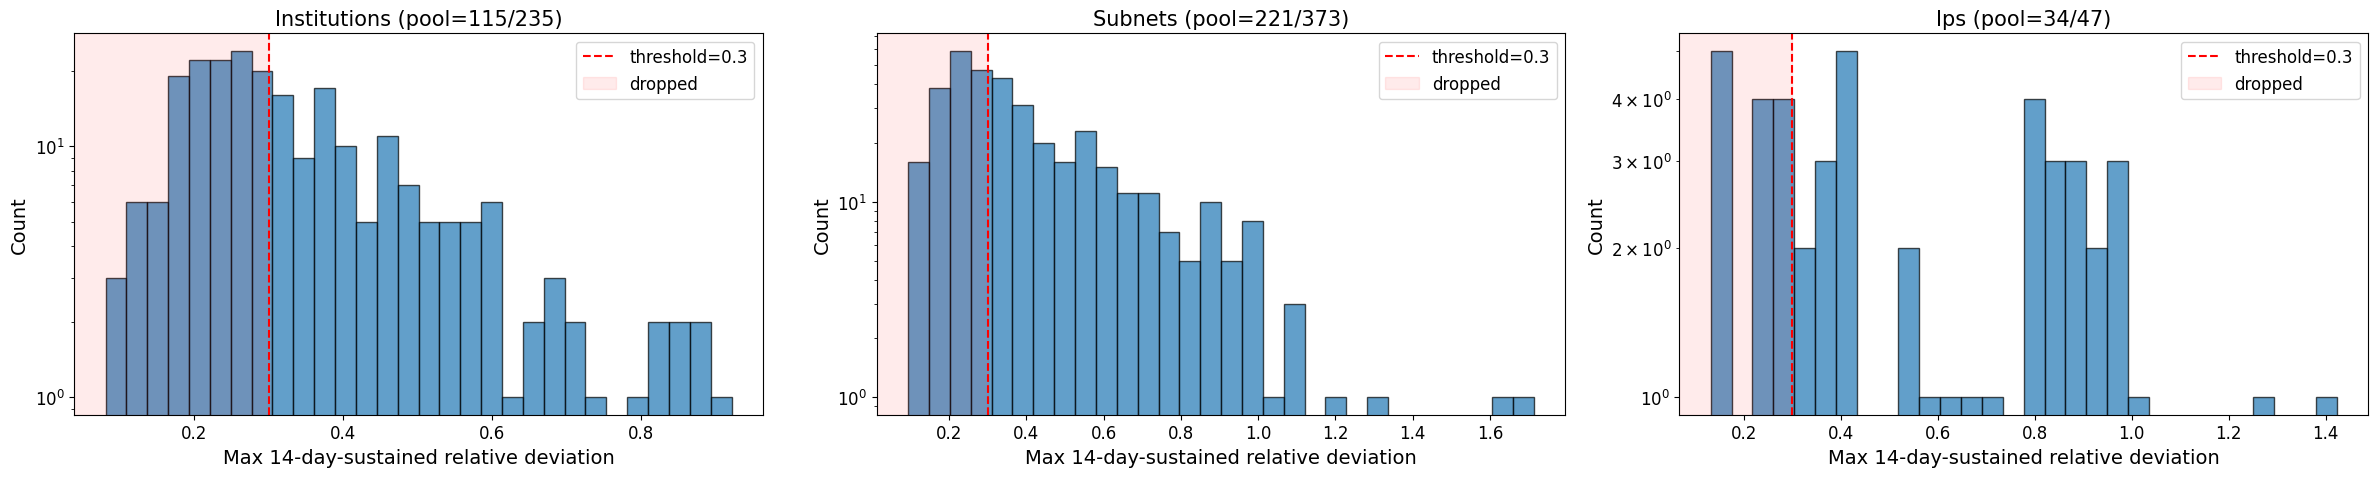

In [5]:
p = BENCH_PARAMS["min_drift_days"]
plot_pool_distribution(
    [(sweep_scores[s], s.capitalize()) for s in sources],
    metric_col=f"S_p{p}",
    threshold=BENCH_PARAMS["threshold"],
    xlabel=f"Max {p}-day-sustained relative deviation",
    log_y=True,
)

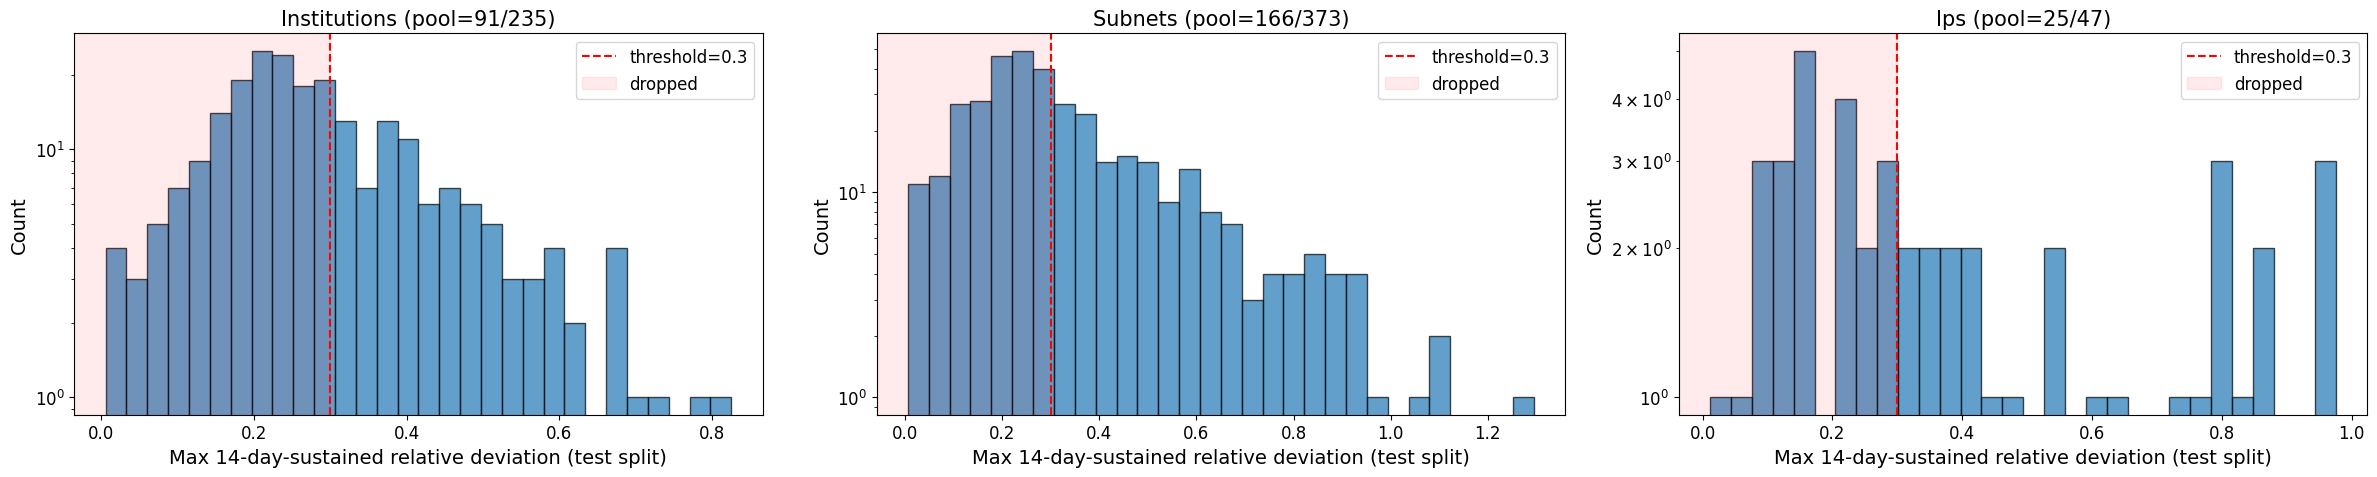

In [6]:
plot_pool_distribution(
    [(sweep_scores[s], s.capitalize()) for s in sources],
    metric_col=f"S_p{p}_test",
    threshold=BENCH_PARAMS["threshold"],
    xlabel=f"Max {p}-day-sustained relative deviation (test split)",
    log_y=True,
)

## 3 — Selection

Apply sparsity filter (≥ 90% active), then select series with sustained drift that overlaps the test set.

In [7]:
selected = {}
pool_sizes = {}

for source in sources:
    ids, pool_size, _ = select_source(BENCHMARK, source, AGGREGATION)
    selected[source] = ids
    pool_sizes[source] = pool_size

print_summary(
    BENCHMARK,
    selected,
    pool_sizes,
    threshold=BENCH_PARAMS["threshold"],
    threshold_name=BENCH_PARAMS["metric_col"],
    sample_size=BENCH_PARAMS["sample_size"],
    seed=RANDOM_SEED,
    extra_info=f"Filter: has_drift & drift_in_test | Min drift: {BENCH_PARAMS['min_drift_days']} days",
)

  institutions: 235/283 pass sparsity, pool=91 — selected 25
  subnets: 373/548 pass sparsity, pool=166 — selected 25
  ips: 47/1000 pass sparsity, pool=25 — selected 25

DRIFT BENCHMARK - Selected Series
Threshold: max_rel_dev >= 0.3
Selection: Random sample of 25 from qualifying pool
Filter: has_drift & drift_in_test | Min drift: 14 days
Random seed: 42

institutions (25): [4, 11, 26, 38, 53, 61, 69, 77, 89, 92, 103, 107, 123, 127, 141, 154, 164, 186, 195, 200, 202, 211, 231, 254, 259]
  Pool size: 91
subnets (25): [33, 44, 50, 51, 58, 59, 67, 80, 86, 117, 142, 154, 189, 248, 250, 262, 310, 316, 319, 326, 341, 403, 408, 425, 517]
  Pool size: 166
ips (25): [120, 122, 1367, 1368, 1580, 1605, 1774, 3271, 10256, 10396, 11254, 41990, 44252, 75195, 78471, 109544, 121596, 171452, 195100, 242764, 259860, 565727, 605036, 617662, 745827]
  Pool size: 25


## 4 — Detailed scores for selected series

In [8]:
for source in sources:
    _, id_col = SOURCE_MAP[source]
    df_s = scores[source]
    sel = df_s[df_s[id_col].isin(selected[source])].sort_values("max_rel_dev", ascending=False)
    print(f"\n{source.capitalize()} — selected series scores:")
    display(sel)


Institutions — selected series scores:


,id_institution,ratio_active,has_drift,drift_in_test,max_rel_dev,drift_fraction,n_drift_events
265,259.0,0.994640,True,True,2.808137,0.200481,5
191,26.0,0.963547,True,True,1.769953,0.049308,2
18,254.0,0.998834,True,True,1.602299,0.015832,2
112,89.0,0.998461,True,True,1.515926,0.008561,2
145,186.0,0.999901,True,True,1.414508,0.053303,1
160,231.0,0.995583,True,True,1.367579,0.029456,3
187,61.0,1.000000,True,True,1.323880,0.013078,1
67,127.0,0.999429,True,True,1.321428,0.016626,1
108,11.0,0.999231,True,True,1.302540,0.032210,2
163,92.0,0.985384,True,True,1.105655,0.061542,2



Subnets — selected series scores:


,id_institution_subnet,ratio_active,has_drift,drift_in_test,max_rel_dev,drift_fraction,n_drift_events
360,51.0,0.997891,True,True,3.424231,0.161274,3
104,67.0,0.993474,True,True,3.395457,0.056504,2
277,44.0,0.992010,True,True,3.181990,0.061517,2
178,248.0,0.999801,True,True,2.802486,0.161646,3
137,80.0,0.998238,True,True,2.536645,0.052335,4
67,117.0,1.000000,True,True,2.440802,0.055536,2
321,408.0,0.999628,True,True,2.144957,0.047198,3
501,86.0,0.974564,True,True,2.101140,0.095464,2
264,50.0,0.986922,True,True,2.032272,0.022780,1
511,33.0,0.999826,True,True,1.860120,0.107623,4



Ips — selected series scores:


,id_ip,ratio_active,has_drift,drift_in_test,max_rel_dev,drift_fraction,n_drift_events
283,242764.0,0.940022,True,True,3.425510,0.221971,6
936,617662.0,0.939128,True,True,3.335229,0.355303,3
394,11254.0,0.955457,True,True,3.313169,0.310983,6
208,120.0,0.991290,True,True,2.998168,0.197652,6
287,565727.0,0.973969,True,True,2.995775,0.281726,3
398,605036.0,0.991340,True,True,2.877652,0.125440,2
853,41990.0,0.968981,True,True,2.543508,0.114274,3
404,10396.0,0.999429,True,True,2.530564,0.152960,6
34,1580.0,0.996848,True,True,2.365359,0.085066,3
260,195100.0,0.984242,True,True,2.125561,0.121718,6


## 5 — Verification plots

For a few selected series per level: raw series with moving averages, relative deviation, and drift regions highlighted.

In [9]:
scale = AGG_PARAMS["daily_period"] / 24
SHORT_WINDOW = int(BENCH_PARAMS["short_window_factor"] * scale)
LONG_WINDOW = int(BENCH_PARAMS["long_window_factor"] * scale)
REL_THRESHOLD = BENCH_PARAMS["threshold"]
MIN_DRIFT_STEPS = int(BENCH_PARAMS["min_drift_days"] * 24 * scale)
SHORT_HOURS = SHORT_WINDOW * STEP_MINUTES / 60
LONG_HOURS = LONG_WINDOW * STEP_MINUTES / 60


def _find_sustained_drift_mask(rel_dev, rel_threshold, min_drift_steps):
    above = (rel_dev > rel_threshold).values
    mask = np.zeros(len(above), dtype=bool)
    i = 0
    while i < len(above):
        if above[i]:
            j = i
            while j < len(above) and above[j]:
                j += 1
            if (j - i) >= min_drift_steps:
                mask[i:j] = True
            i = j
        else:
            i += 1
    return pd.Series(mask, index=rel_dev.index)


def plot_drift_verification(df, id_col, ts_id, level_label):
    grp = df[df[id_col] == ts_id].reset_index(drop=True)
    t = grp["datetime"]
    y = grp["n_bytes"].astype(float)

    ma_short = y.rolling(window=SHORT_WINDOW, min_periods=SHORT_WINDOW).mean()
    ma_long = y.rolling(window=LONG_WINDOW, min_periods=LONG_WINDOW).mean()

    valid_idx = ma_long.dropna().index
    valid_idx = valid_idx[ma_long.loc[valid_idx] > 0]
    rel_dev = (ma_short.loc[valid_idx] - ma_long.loc[valid_idx]).abs() / ma_long.loc[valid_idx]

    drift_mask = _find_sustained_drift_mask(rel_dev, REL_THRESHOLD, MIN_DRIFT_STEPS)

    rel_full = pd.Series(np.nan, index=y.index)
    rel_full.loc[valid_idx] = rel_dev.values
    sustained_full = pd.Series(False, index=y.index)
    sustained_full.loc[valid_idx] = drift_mask.values

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(t, y.values, linewidth=0.3, alpha=0.5, label="raw")
    axes[0].plot(t, ma_short.values, linewidth=1, label=f"MA({SHORT_HOURS:.0f}h)", color="orange")
    axes[0].plot(t, ma_long.values, linewidth=1, label=f"MA({LONG_HOURS:.0f}h)", color="green")
    axes[0].set_ylabel("n_bytes")
    axes[0].set_title(f"{level_label} | ID = {int(ts_id)}  —  Raw n_bytes + Moving Averages")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, rel_full.values * 100, linewidth=0.5)
    axes[1].axhline(REL_THRESHOLD * 100, color="red", linestyle="--", alpha=0.7,
                    label=f"threshold {REL_THRESHOLD*100:.0f}%")
    axes[1].set_ylabel("Relative deviation (%)")
    axes[1].set_title("|MA_short \u2212 MA_long| / MA_long")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, y.values, linewidth=0.3, alpha=0.5)
    axes[2].fill_between(t, 0, y.max(),
                         where=sustained_full.values, alpha=0.3, color="red",
                         label=f"sustained drift (\u2265{BENCH_PARAMS['min_drift_days']}d)")
    axes[2].set_ylabel("n_bytes")
    axes[2].set_xlabel("Time")
    axes[2].set_title("Drift regions highlighted")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

100%|████████████████████████████| 3/3 [00:07<00:00,  2.65s/it]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [164  26 195], Length=3
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch size: 128


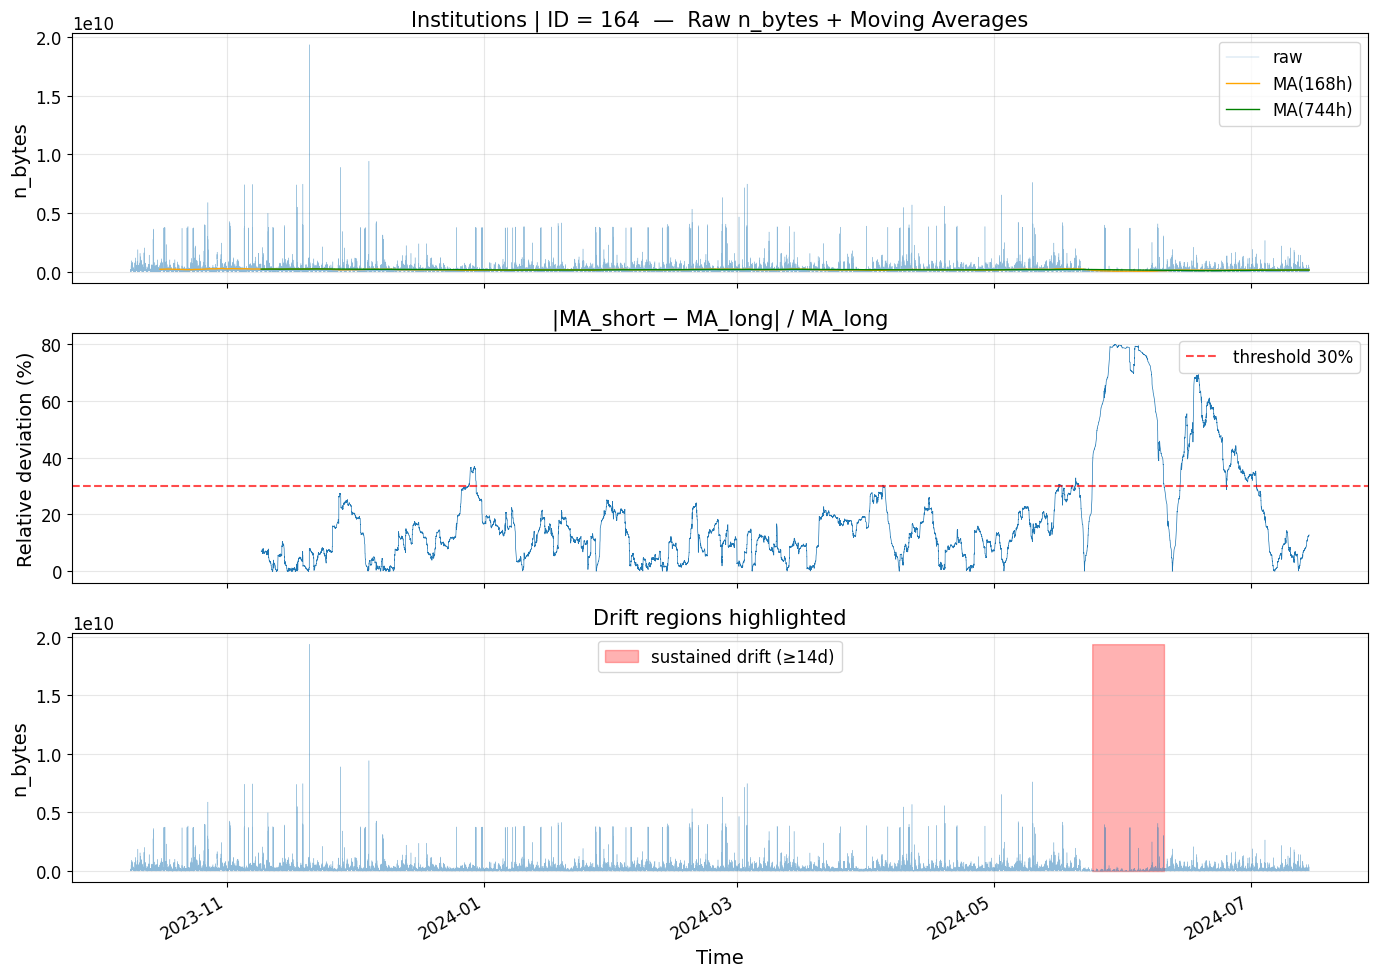

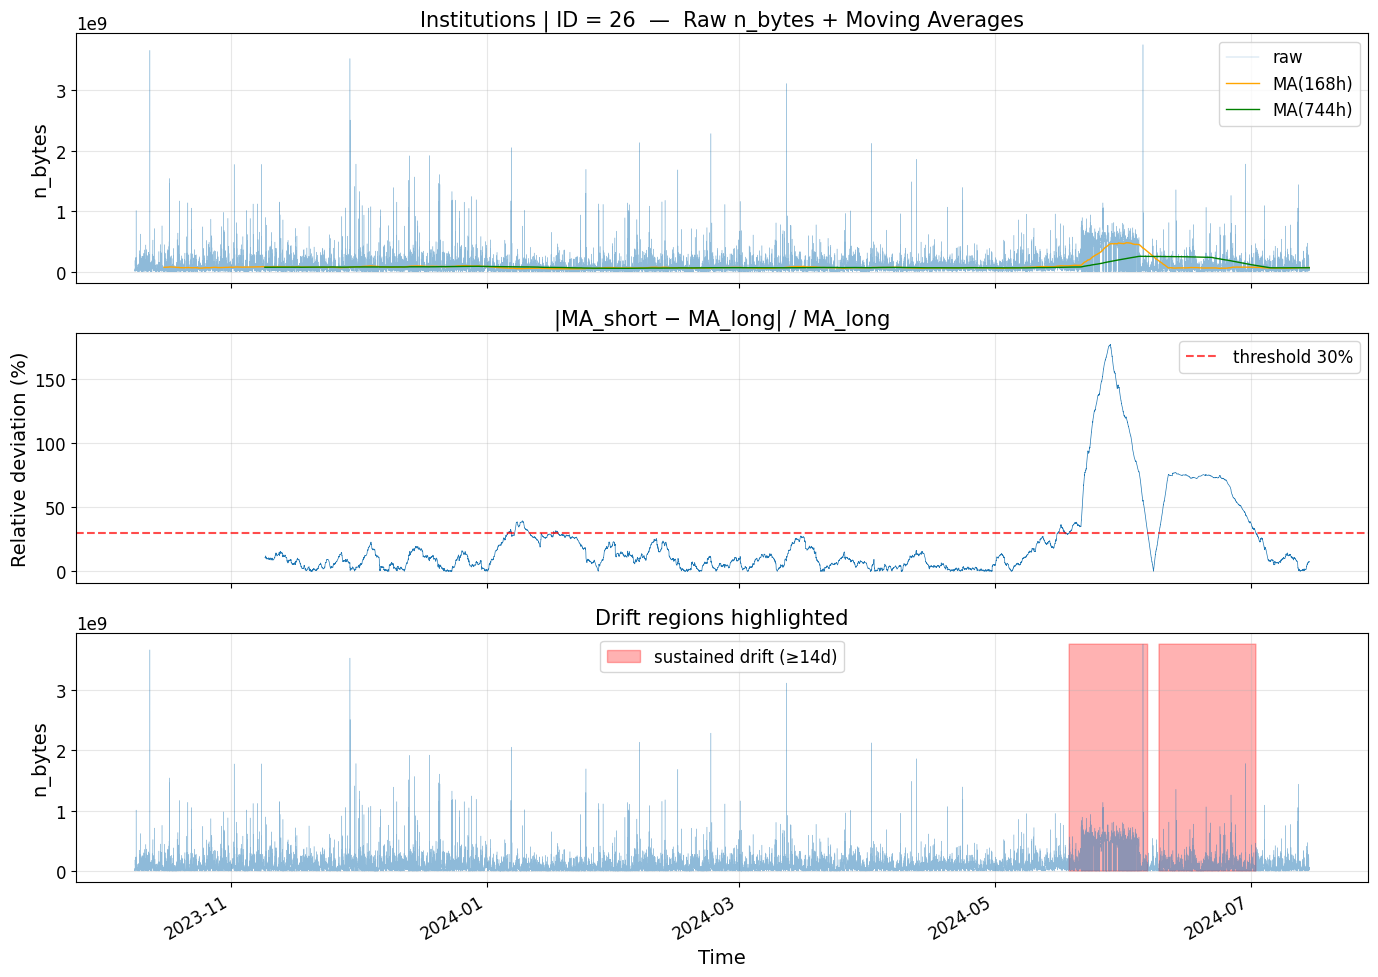

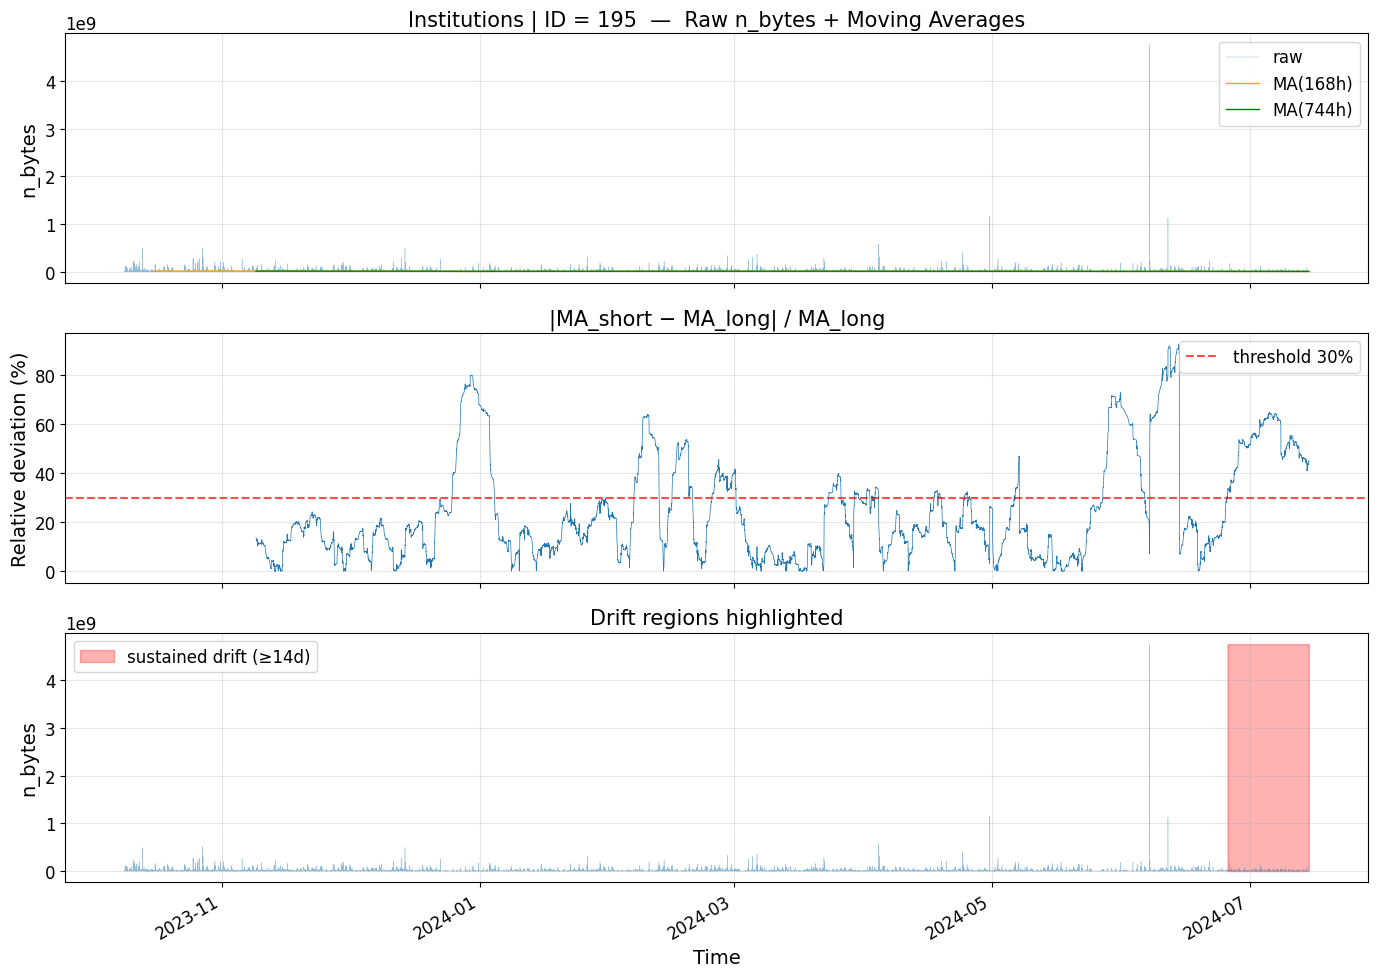

100%|████████████████████████████| 3/3 [00:07<00:00,  2.64s/it]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [ 50 316 326], Length=3
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch siz

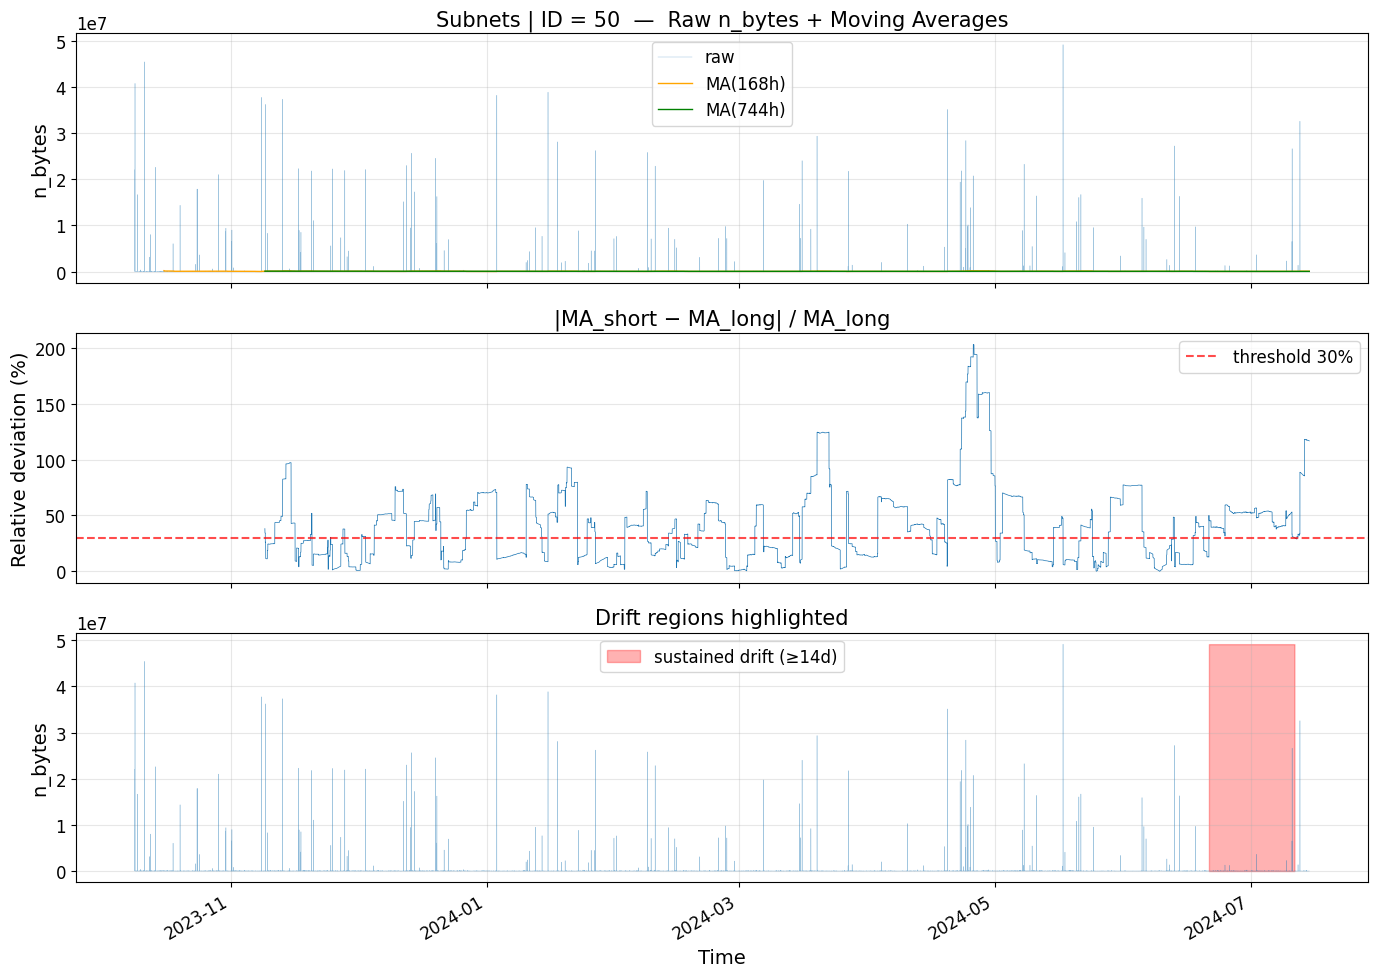

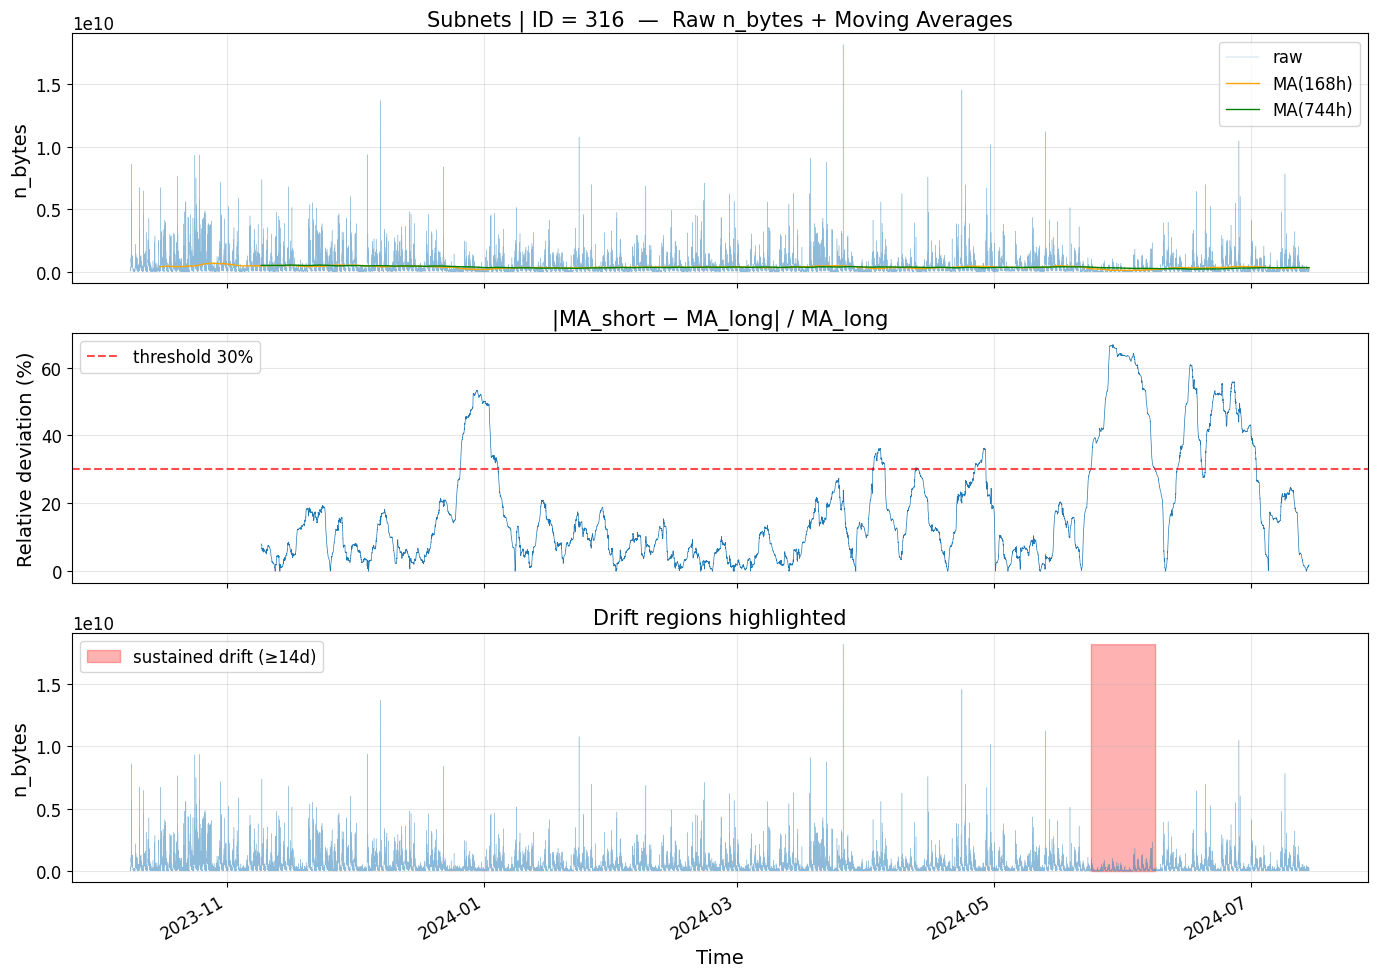

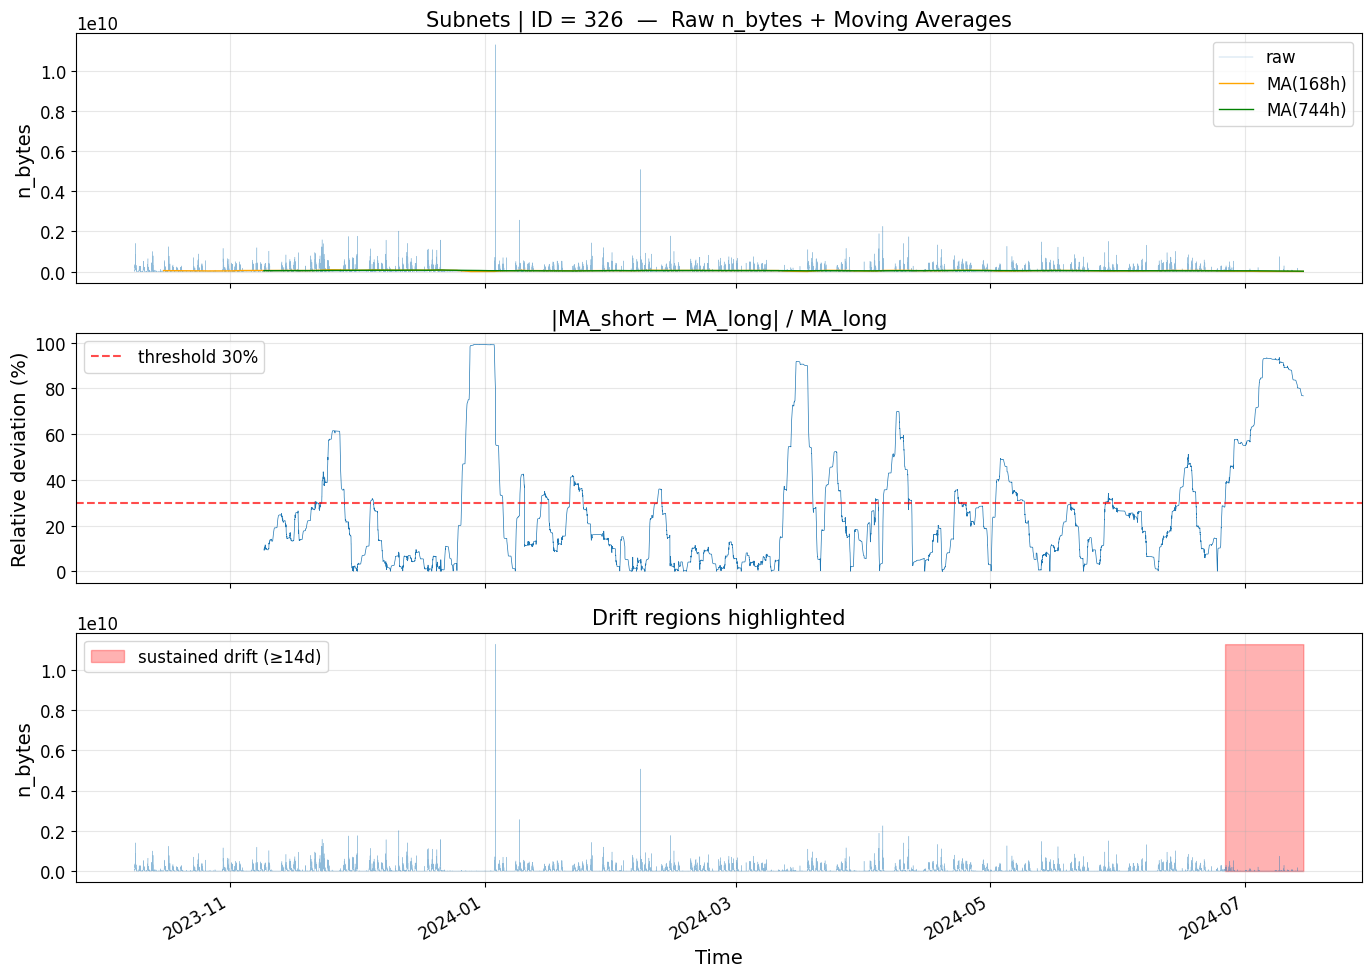

100%|████████████████████████████| 3/3 [00:07<00:00,  2.60s/it]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.IP_ADDRESSES_SAMPLE

    Time series
        Time series IDS: [ 44252 617662 195100], Length=3
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test 

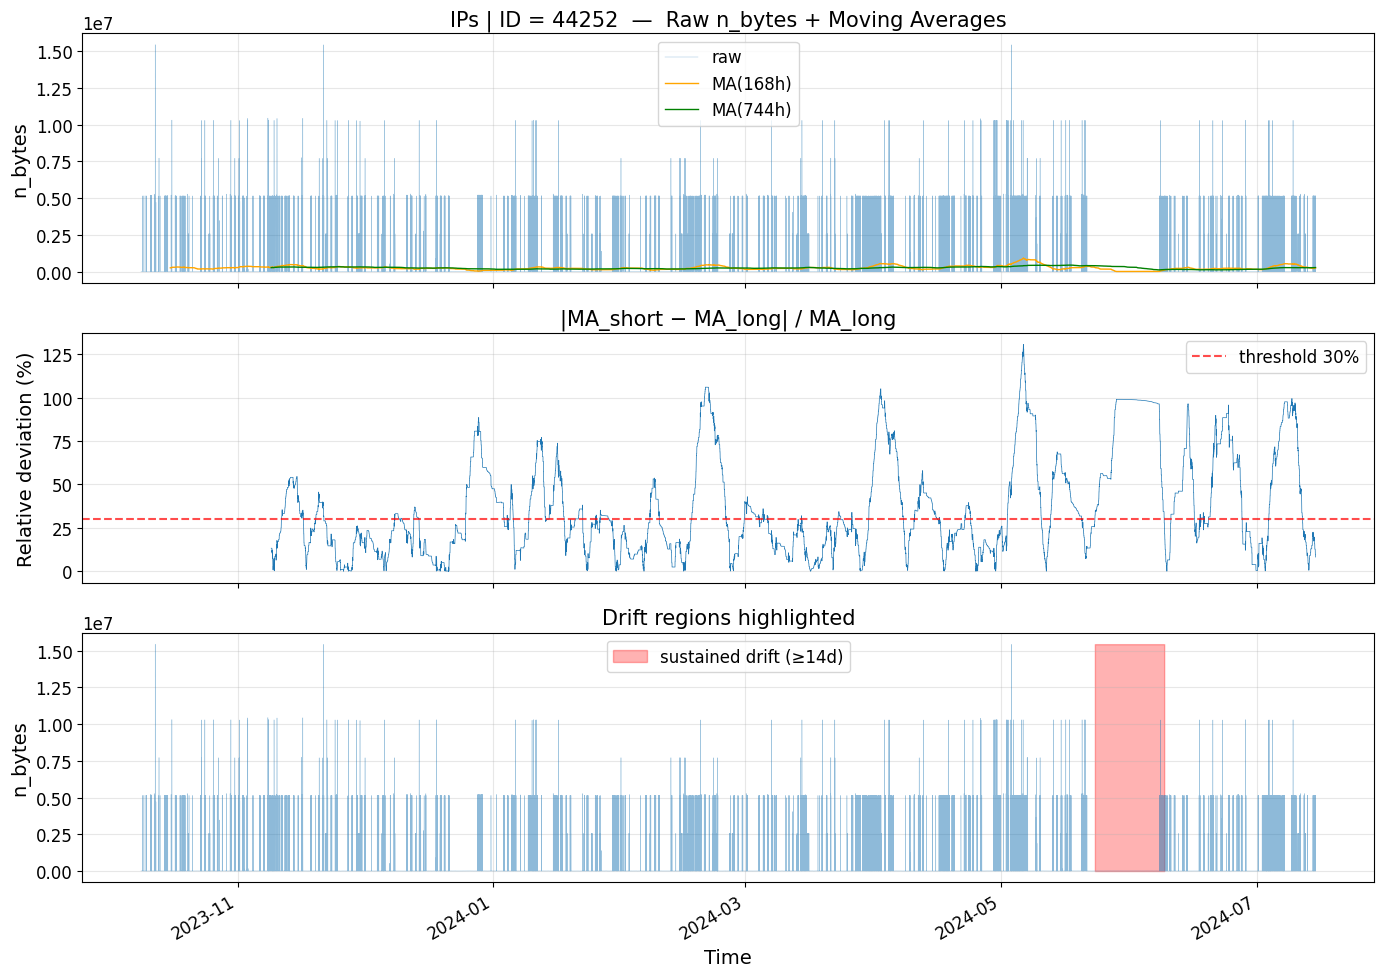

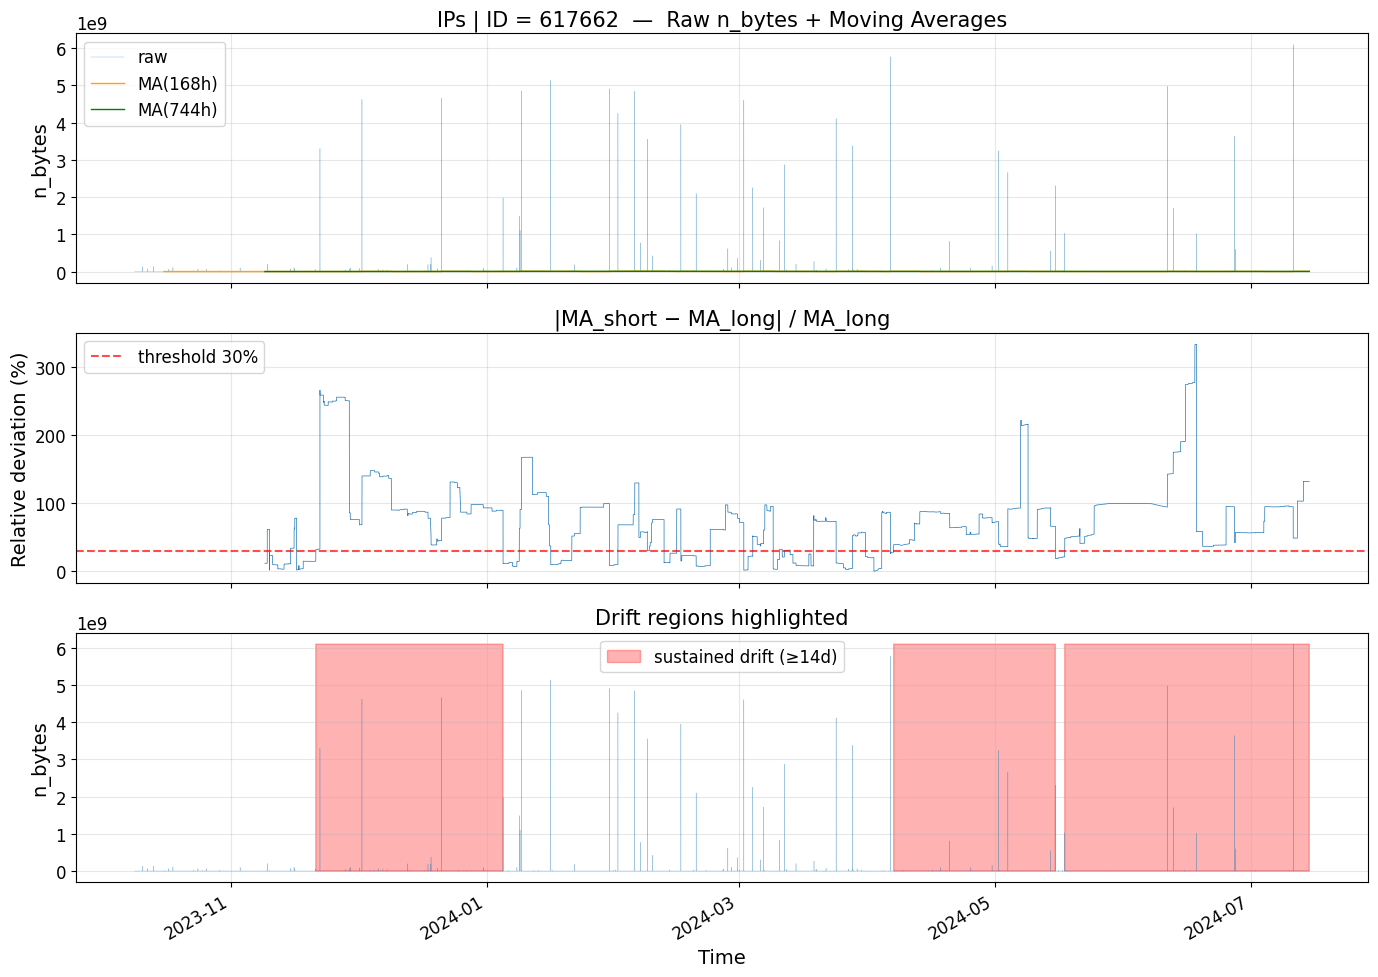

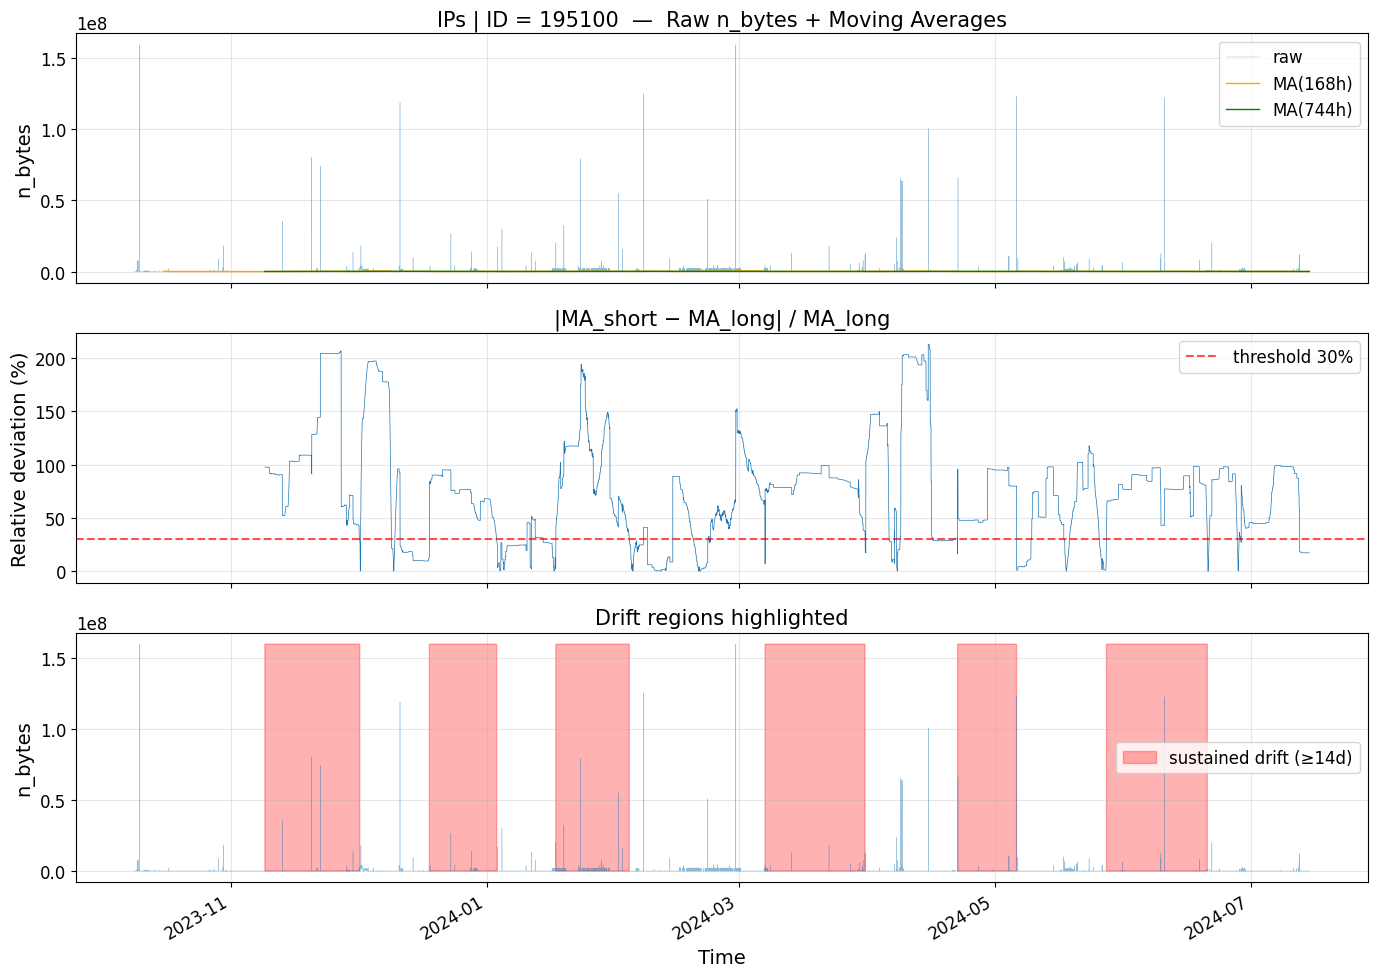

In [10]:
N_VERIFY = 3
rng = np.random.default_rng(RANDOM_SEED)
level_labels = {"institutions": "Institutions", "subnets": "Subnets", "ips": "IPs"}

for source in sources:
    _, id_col = SOURCE_MAP[source]
    verify_ids = rng.choice(selected[source], size=min(N_VERIFY, len(selected[source])), replace=False).tolist()
    data = load_dataset(source, aggregation=AGG_PARAMS["enum"], time_range=AGG_PARAMS["time_range"], ts_ids=verify_ids)
    df = data["df"]
    label = level_labels[source]
    print(f"\n{'='*60}")
    print(f"{source.upper()} — verifying {len(verify_ids)} series")
    print(f"{'='*60}")
    for ts_id in verify_ids:
        plot_drift_verification(df, id_col, ts_id, label)

## 6 — Save selection

In [11]:
save_selection(selected, BENCHMARK, AGGREGATION)

Saved selected_ids/10min/DRIFT.csv (75 series)


'selected_ids/10min/DRIFT.csv'